# Readers

Notebook was prepared as a sample tool to read data from different data sources. Moreover notebook includes some simple exploratory data analysis for data overview purposes.

In [190]:
import os
from pathlib import Path
from pprint import pprint as print

import requests
import pandas as pd
import json
import numpy as np


# Setup pitch and plot
from mplsoccer import Pitch, VerticalPitch


In [201]:
CURRENT_WORKING_DIR = Path(os.getcwd())
WORKING_DIR = CURRENT_WORKING_DIR.parent
DATA_DIR = WORKING_DIR / "data"

## SkillCorner

Data loading is based on the SkillCorner tutorial guide. More information under below link :arrow_down:

**Link:** https://github.com/SkillCorner/opendata

In [85]:
# Content URL for the SkillCorner opendata repository
content_url = "https://api.github.com/repos/SkillCorner/opendata/contents/data/matches"

# Get the list of available matches
response = requests.get(content_url)
matches = response.json()

# Display available match IDs
match_ids = [match['name'] for match in matches if match['type'] == 'dir']
print(f"Available matches: {len(match_ids)}")
print(match_ids)

'Available matches: 10'
['1886347',
 '1899585',
 '1925299',
 '1953632',
 '1996435',
 '2006229',
 '2011166',
 '2013725',
 '2015213',
 '2017461']


### Data Readers ###

In [171]:
# Example: Load tracking data for a specific match
match_id = 2017461

# Construct the raw tracking content URL
content_tracking_url = content_url + f"/{match_id}/{match_id}_tracking_extrapolated.jsonl"  # Data is stored using GitLFS
content_tracking_data = pd.read_json(content_tracking_url, lines=True)
print(f"Downloaded tracking data URL: {content_tracking_data['download_url'][0]}")

# Construct the raw match content URL
content_match_url = content_url + f"/{match_id}/{match_id}_match.json"  # Data is stored using GitLFS
content_match_data = pd.read_json(content_match_url, lines=True)
print(f"Downloaded match data URL: {content_match_data['download_url'][0]}")

('Downloaded tracking data URL: '
 'https://media.githubusercontent.com/media/SkillCorner/opendata/master/data/matches/2017461/2017461_tracking_extrapolated.jsonl')
('Downloaded match data URL: '
 'https://raw.githubusercontent.com/SkillCorner/opendata/master/data/matches/2017461/2017461_match.json')


## Player data

Extract player and ball data. Preprocess raw data frame into processed, ready for analytics data frame. 

In [172]:
def preprocess_tracking_data(raw_data: pd.DataFrame) -> pd.DataFrame:
    """Preprocess tracking data by normalizing nested JSON fields and extracting relevant information.

    Args:
        raw_data (pd.DataFrame): Raw tracking data containing nested JSON fields.

    Returns:
        pd.DataFrame: Preprocessed tracking data with normalized fields.
    """
    raw_df = pd.json_normalize(
        raw_data.to_dict("records"),
        "player_data",
        ["frame", "timestamp", "period", "possession", "ball_data"],
    )
    raw_df["possession_player_id"] = raw_df["possession"].apply(
    lambda x: x.get("player_id")
        )
    raw_df["possession_group"] = raw_df["possession"].apply(lambda x: x.get("group"))
    
    # Expand the ball_data with json_normalize
    raw_df[["ball_x", "ball_y", "ball_z", "is_detected_ball"]] = pd.json_normalize(
        raw_df.ball_data
    )
    # Drop the original 'possession' column if you no longer need it
    raw_df = raw_df.drop(columns=["possession", "ball_data"])
    
    return raw_df

In [173]:
# Read the JSON tracking data as a JSON object
raw_tracking_data = pd.read_json(content_tracking_data['download_url'][0], lines=True)

# Process the raw data
processed_tracking_df = preprocess_tracking_data(raw_tracking_data)
processed_tracking_df["match_id"] = match_id
processed_tracking_df.head()

,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,ball_x,ball_y,ball_z,is_detected_ball,match_id
0,-38.16,1.51,51678,False,2510,2025-11-30,1.0,NaN,None,-0.46,-0.12,0.14,True,2017461
1,-20.78,3.31,51013,True,2510,2025-11-30,1.0,NaN,None,-0.46,-0.12,0.14,True,2017461
2,-20.93,14.81,51685,True,2510,2025-11-30,1.0,NaN,None,-0.46,-0.12,0.14,True,2017461
3,-21.03,-8.49,800322,True,2510,2025-11-30,1.0,NaN,None,-0.46,-0.12,0.14,True,2017461
4,-8.60,23.72,811820,True,2510,2025-11-30,1.0,NaN,None,-0.46,-0.12,0.14,True,2017461


In [183]:
### Read all matches tracking data
all_matches_tracking = []
for match in match_ids:
    try:
        content_tracking_url = content_url + f"/{match}/{match}_tracking_extrapolated.jsonl"
        content_tracking_data = pd.read_json(content_tracking_url, lines=True)
        raw_tracking_data = pd.read_json(content_tracking_data['download_url'][0], lines=True)
        processed_tracking_df = preprocess_tracking_data(raw_tracking_data)
        processed_tracking_df["match_id"] = int(match)
        all_matches_tracking.append(processed_tracking_df)
        print(f"Processed match ID: {match}")
    except Exception as e:
        print(f"Failed to process match ID: {match}. Error: {e}")

'Processed match ID: 1886347'
'Processed match ID: 1899585'
'Processed match ID: 1925299'
'Processed match ID: 1953632'
'Processed match ID: 1996435'
'Processed match ID: 2006229'
'Processed match ID: 2011166'
'Processed match ID: 2013725'
'Processed match ID: 2015213'
'Processed match ID: 2017461'


In [184]:
all_matches_tracking_df = pd.concat(all_matches_tracking, ignore_index=True)
all_matches_tracking_df.head()

,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,ball_x,ball_y,ball_z,is_detected_ball,match_id
0,-39.63,-0.08,51009,False,10,2025-11-30,1.0,NaN,None,0.32,0.38,0.13,True,1886347
1,-19.21,-9.18,176224,True,10,2025-11-30,1.0,NaN,None,0.32,0.38,0.13,True,1886347
2,-21.83,0.47,51649,True,10,2025-11-30,1.0,NaN,None,0.32,0.38,0.13,True,1886347
3,-1.16,-32.47,50983,True,10,2025-11-30,1.0,NaN,None,0.32,0.38,0.13,True,1886347
4,-18.88,15.73,735578,True,10,2025-11-30,1.0,NaN,None,0.32,0.38,0.13,True,1886347


In [203]:
all_matches_tracking_df.to_csv(DATA_DIR / "all_matches_tracking.csv", index=False)

## Match data

In [174]:
def time_to_seconds(time_str):
    if time_str is None:
        return 90 * 60  # 120 minutes = 7200 seconds
    h, m, s = map(int, time_str.split(":"))
    return h * 3600 + m * 60 + s


def preprocess_players_data(raw_match_df: pd.DataFrame) -> pd.DataFrame:
    """Preprocess match data by converting time strings to seconds.

    Args:
        raw_match (pd.DataFrame): Raw match data containing time strings.
    Returns:
        pd.DataFrame: Preprocessed players data with time in seconds.
    """
    # Extract relevant fields from nested JSON structures
    players_df = pd.json_normalize(
        raw_match_df.to_dict("records"),
        record_path="players",
        meta=[
            "home_team_score",
            "away_team_score",
            "date_time",
            "home_team_side",
            "home_team.name",
            "home_team.id",
            "away_team.name",
            "away_team.id",
        ],  # data we keep
    )
    # Take only players who played and create their total time
    mask = (players_df.start_time.isna()) & (players_df.end_time.isna())
    players_df = players_df[~mask]
    players_df["total_time"] = players_df["end_time"].apply(time_to_seconds) - players_df["start_time"].apply(time_to_seconds)
    
    # Create a flag for GK
    players_df["is_gk"] = players_df["player_role.acronym"] == "GK"

    # Add a match name column
    players_df["match_name"] = (
        players_df["home_team.name"] + " vs " + players_df["away_team.name"]
    )
    # Add a flag if the given player is home or away
    players_df["home_away_player"] = np.where(
        players_df.team_id == players_df["home_team.id"], "Home", "Away"
    )
    # Create flag from player
    players_df["team_name"] = np.where(
        players_df.team_id == players_df["home_team.id"],
        players_df["home_team.name"],
        players_df["away_team.name"],
    )
    # Figure out sides
    players_df[["home_team_side_1st_half", "home_team_side_2nd_half"]] = (
        players_df["home_team_side"]
        .astype(str)
        .str.strip("[]")
        .str.replace("'", "")
        .str.split(", ", expand=True)
    )
    # Clean up sides
    players_df["direction_player_1st_half"] = np.where(
        players_df.home_away_player == "Home",
        players_df.home_team_side_1st_half,
        players_df.home_team_side_2nd_half,
    )
    players_df["direction_player_2nd_half"] = np.where(
        players_df.home_away_player == "Home",
        players_df.home_team_side_2nd_half,
        players_df.home_team_side_1st_half,
    )
    # Clean up and keep the columns that we want to keep about
    columns_to_keep = [
        "start_time",
        "end_time",
        "match_name",
        "date_time",
        "home_team.name",
        "away_team.name",
        "id",
        "short_name",
        "number",
        "team_id",
        "team_name",
        "player_role.position_group",
        "total_time",
        "player_role.name",
        "player_role.acronym",
        "is_gk",
        "direction_player_1st_half",
        "direction_player_2nd_half",
    ]
    players_df = players_df[columns_to_keep]
    return players_df

In [175]:
# Read the JSON match data as a JSON object
response = requests.get(content_match_data['download_url'][0])
raw_match_data = response.json()
raw_match_df = pd.json_normalize(raw_match_data, max_level=2)

In [176]:
processed_players_df = preprocess_players_data(raw_match_df)
processed_players_df.head()

,start_time,end_time,match_name,date_time,home_team.name,away_team.name,id,short_name,number,team_id,team_name,player_role.position_group,total_time,player_role.name,player_role.acronym,is_gk,direction_player_1st_half,direction_player_2nd_half
0,01:23:12,None,Melbourne Victory Football Club vs Auckland FC,2025-05-17T09:35:00Z,Melbourne Victory Football Club,Auckland FC,795521,A. Badolato,23,868,Melbourne Victory Football Club,Wide Attacker,408,Right Winger,RW,False,left_to_right,right_to_left
1,01:02:21,None,Melbourne Victory Football Club vs Auckland FC,2025-05-17T09:35:00Z,Melbourne Victory Football Club,Auckland FC,965685,L. Gillion,14,4177,Auckland FC,Wide Attacker,1659,Left Winger,LW,False,right_to_left,left_to_right
2,01:14:54,None,Melbourne Victory Football Club vs Auckland FC,2025-05-17T09:35:00Z,Melbourne Victory Football Club,Auckland FC,31147,T. Smith,5,4177,Auckland FC,Central Defender,906,Center Back,CB,False,right_to_left,left_to_right
3,00:00:00,01:23:12,Melbourne Victory Football Club vs Auckland FC,2025-05-17T09:35:00Z,Melbourne Victory Football Club,Auckland FC,50955,N. Velupillay,17,868,Melbourne Victory Football Club,Wide Attacker,4992,Left Winger,LW,False,left_to_right,right_to_left
4,00:00:00,01:19:39,Melbourne Victory Football Club vs Auckland FC,2025-05-17T09:35:00Z,Melbourne Victory Football Club,Auckland FC,23418,F. Gallegos,28,4177,Auckland FC,Midfield,4779,Left Midfield,LM,False,right_to_left,left_to_right


## Merging data frame

In [154]:
merged_df = processed_tracking_df.merge(
    processed_players_df, left_on="player_id", right_on="id", how="left"
)
merged_df.head()

,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,ball_x,...,number,team_id,team_name,player_role.position_group,total_time,player_role.name,player_role.acronym,is_gk,direction_player_1st_half,direction_player_2nd_half
0,-39.61,0.71,34718,False,10,2025-11-30,1.0,23909.0,away team,0.73,...,1,867,Wellington Phoenix FC,Other,5400,Goalkeeper,GK,True,left_to_right,right_to_left
1,-18.99,10.85,698137,True,10,2025-11-30,1.0,23909.0,away team,0.73,...,15,867,Wellington Phoenix FC,Central Defender,5400,Center Back,CB,False,left_to_right,right_to_left
2,-17.05,-11.54,799092,True,10,2025-11-30,1.0,23909.0,away team,0.73,...,27,867,Wellington Phoenix FC,Central Defender,5400,Right Center Back,RCB,False,left_to_right,right_to_left
3,-20.05,1.28,42510,True,10,2025-11-30,1.0,23909.0,away team,0.73,...,4,867,Wellington Phoenix FC,Central Defender,5400,Left Center Back,LCB,False,left_to_right,right_to_left
4,-1.41,-30.06,51017,True,10,2025-11-30,1.0,23909.0,away team,0.73,...,6,867,Wellington Phoenix FC,Full Back,3610,Right Wing Back,RWB,False,left_to_right,right_to_left


In [155]:
print(f"Processed tracking data shape: {processed_tracking_df.shape}")
print(f"Processed players data shape: {processed_players_df.shape}")
print(f"Merged data shape: {merged_df.shape}")

'Processed tracking data shape: (894982, 14)'
'Processed players data shape: (30, 18)'
'Merged data shape: (894982, 32)'


**Analysis ideas:**
 - free kicks, corners - players movements
 - Midfielders - off ball movements, number of offensive / defensive passes, passes based on the number of opponent players
 - Center Backs - off ball movements in offensive part of the game, passes
 - Before goal team movement

**ML model ideas:**
- Clustering - players similarities
    - off ball movements

In [168]:
merged_df.columns

Index(['x', 'y', 'player_id', 'is_detected', 'frame', 'timestamp', 'period',
       'possession_player_id', 'possession_group', 'ball_x', 'ball_y',
       'ball_z', 'is_detected_ball', 'match_id', 'start_time', 'end_time',
       'match_name', 'date_time', 'home_team.name', 'away_team.name', 'id',
       'short_name', 'number', 'team_id', 'team_name',
       'player_role.position_group', 'total_time', 'player_role.name',
       'player_role.acronym', 'is_gk', 'direction_player_1st_half',
       'direction_player_2nd_half'],
      dtype='object')

In [156]:
# Filtering for frames with a team in possession
filtered_df = merged_df[
    merged_df["possession_group"].notnull()
].copy()


# We basically want to convert the X and Y to make sure we're always visualizing left to right. A player's XY will depend on the half so the straight average doesn't work

filtered_df["direction_player"] = np.where(
    filtered_df["period"] == 1,
    filtered_df["direction_player_1st_half"],
    filtered_df["direction_player_2nd_half"],
)
filtered_df["x"] = np.where(
    filtered_df["direction_player"] == "right_to_left",
    -filtered_df["x"],
    filtered_df["x"],
)  # Convert X
filtered_df["y"] = np.where(
    filtered_df["direction_player"] == "right_to_left",
    -filtered_df["y"],
    filtered_df["y"],
)  # Convert Y

# Create some flags in case we need them later
filtered_df["possession_team_name"] = np.where(
    filtered_df["possession_group"] == "home team",
    filtered_df["home_team.name"],
    filtered_df["away_team.name"],
)
filtered_df["possession_flag"] = np.where(
    filtered_df["possession_team_name"] == filtered_df["team_name"], "IP", "OOP"
)


# At this point all of our players have their X and Y adjusted from left to right , so we can aggregate for across the game

aggregated_df = (
    filtered_df.groupby(
        [
            "player_id",
            "possession_group",
            "team_name",
            "possession_team_name",
            "possession_flag",  # This will allow us to check the position of the player when the team is in or out of possession
            "start_time",  # With this we can filter in or out the players that came on as subs
            "number",
            "is_gk",
        ]
    )[["x", "y"]]
    .mean()
    .reset_index()
)

aggregated_df.sort_values(["possession_flag", "team_name"])

,player_id,possession_group,team_name,possession_team_name,possession_flag,start_time,number,is_gk,x,y
1,4322,home team,Auckland FC,Auckland FC,IP,00:00:00,2,False,3.139571,-19.046992
5,14736,home team,Auckland FC,Auckland FC,IP,00:00:00,6,False,10.290040,-3.167151
7,23418,home team,Auckland FC,Auckland FC,IP,00:00:00,28,False,6.462969,6.872690
15,31147,home team,Auckland FC,Auckland FC,IP,01:08:31,5,False,-10.845558,-0.570653
17,33697,home team,Auckland FC,Auckland FC,IP,00:00:00,4,False,-7.485203,8.810232
21,38673,home team,Auckland FC,Auckland FC,IP,00:00:00,10,False,20.280626,0.310337
25,43829,home team,Auckland FC,Auckland FC,IP,00:58:04,25,False,12.891695,-1.318949
27,50951,home team,Auckland FC,Auckland FC,IP,00:00:00,22,False,15.664987,3.710749
37,51667,home team,Auckland FC,Auckland FC,IP,00:00:00,23,False,-7.330117,-6.934000
39,133495,home team,Auckland FC,Auckland FC,IP,00:21:41,7,False,1.123207,-2.677677


# Visualization example

Text(0.5, 1.0, 'Wellington Phoenix FC Average Positions in Possession')

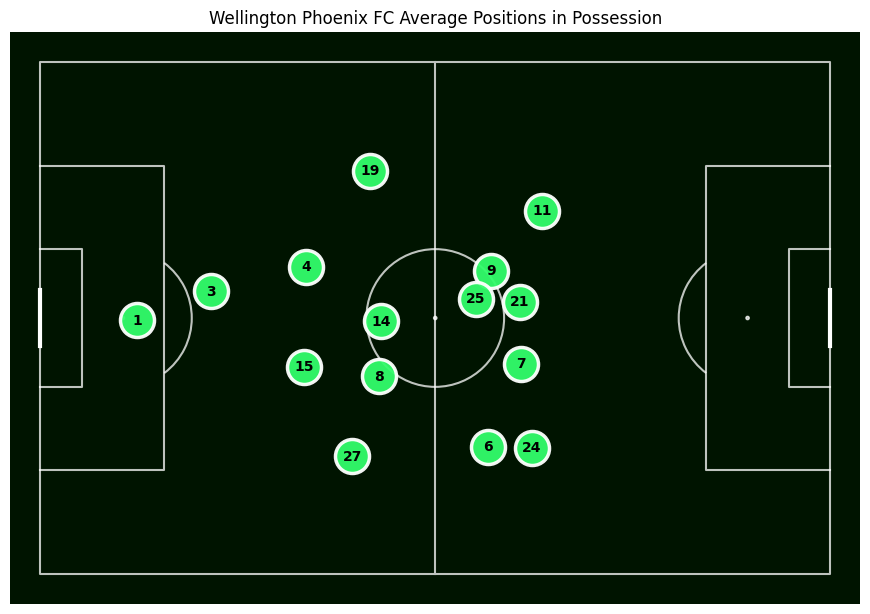

In [157]:
pitch = Pitch(
    pitch_type="skillcorner",
    line_alpha=0.75,
    pitch_length=105,
    pitch_width=68,
    pitch_color="#001400",
    line_color="white",
    linewidth=1.5,
)
fig, ax = pitch.grid(figheight=8, endnote_height=0, title_height=0)


# What to visualize
possession = "IP"  # or 'OOP'
team = aggregated_df.team_name.unique().tolist()[
    1
]  # Pick one team, you can use the name directly

viz_ip = aggregated_df[
    (aggregated_df["possession_flag"] == possession)
    & (aggregated_df["team_name"] == team)
].reset_index(drop=True)


ax.scatter(
    viz_ip["x"],
    viz_ip["y"],
    c="#32FE6B",
    alpha=0.95,
    s=600,
    edgecolors="white",
    linewidths=2.5,
    zorder=10,
    label="team",
)


# Annotate player numbers
for i, row in viz_ip.iterrows():
    ax.text(
        row["x"],
        row["y"],
        str(row["number"]),
        color="black",
        fontweight="bold",
        fontsize=10,
        ha="center",
        va="center",
        zorder=16,
    )

ax.set_title(f"{team} Average Positions in Possession")

Text(0.5, 1.0, 'Wellington Phoenix FC Average Positions in Possession')

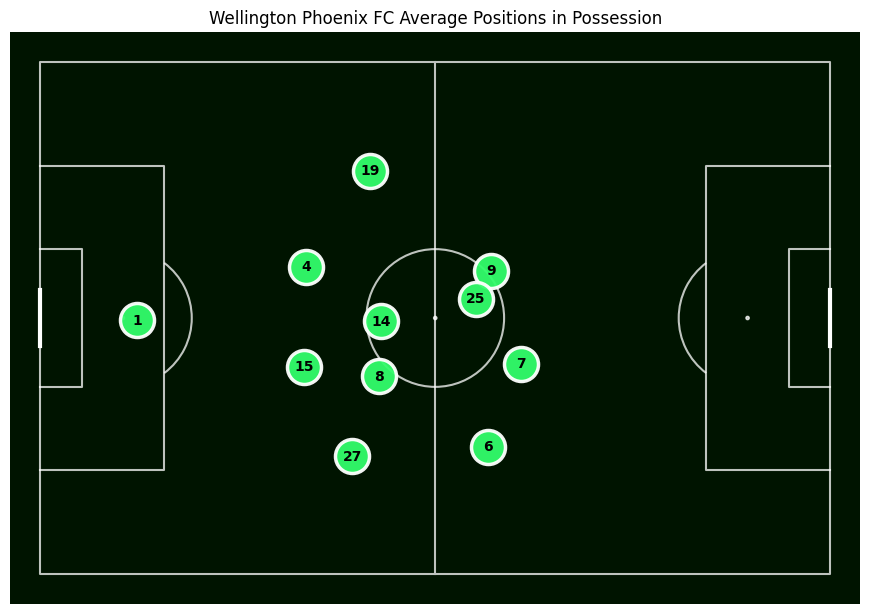

In [158]:
pitch = Pitch(
    pitch_type="skillcorner",
    line_alpha=0.75,
    pitch_length=105,
    pitch_width=68,
    pitch_color="#001400",
    line_color="white",
    linewidth=1.5,
)
fig, ax = pitch.grid(figheight=8, endnote_height=0, title_height=0)


# What to visualize
possession = "IP"  # or 'OOP'
team = aggregated_df.team_name.unique().tolist()[
    1
]  # Pick one team, you can use the name directly

viz_ip = aggregated_df[
    (aggregated_df["possession_flag"] == possession)
    & (aggregated_df["team_name"] == team)
    & (aggregated_df["start_time"] == "00:00:00")
].reset_index(drop=True)


ax.scatter(
    viz_ip["x"],
    viz_ip["y"],
    c="#32FE6B",
    alpha=0.95,
    s=600,
    edgecolors="white",
    linewidths=2.5,
    zorder=10,
    label="team",
)


# Annotate player numbers
for i, row in viz_ip.iterrows():
    ax.text(
        row["x"],
        row["y"],
        str(row["number"]),
        color="black",
        fontweight="bold",
        fontsize=10,
        ha="center",
        va="center",
        zorder=16,
    )

ax.set_title(f"{team} Average Positions in Possession")

In [161]:
processed_tracking_df.columns

Index(['x', 'y', 'player_id', 'is_detected', 'frame', 'timestamp', 'period',
       'possession_player_id', 'possession_group', 'ball_x', 'ball_y',
       'ball_z', 'is_detected_ball', 'match_id'],
      dtype='object')

In [162]:
processed_players_df.columns

Index(['start_time', 'end_time', 'match_name', 'date_time', 'home_team.name',
       'away_team.name', 'id', 'short_name', 'number', 'team_id', 'team_name',
       'player_role.position_group', 'total_time', 'player_role.name',
       'player_role.acronym', 'is_gk', 'direction_player_1st_half',
       'direction_player_2nd_half'],
      dtype='object')

In [165]:
player_name

'K. Barbarouses'

In [180]:
columns_ = ["x_adjusted", "y_adjusted", "timestamp"]
player_tracking[columns_]

,x_adjusted,y_adjusted,timestamp
8,0.50,-0.25,2025-11-30 00:00:00.000
30,0.51,-0.26,2025-11-30 00:00:00.100
52,0.53,-0.28,2025-11-30 00:00:00.200
74,0.56,-0.31,2025-11-30 00:00:00.300
96,0.60,-0.35,2025-11-30 00:00:00.400
...,...,...,...
894891,-4.86,-5.08,2025-11-30 01:36:06.500
894913,-4.96,-4.98,2025-11-30 01:36:06.600
894935,-5.09,-4.87,2025-11-30 01:36:06.700
894957,-5.23,-4.77,2025-11-30 01:36:06.800


In [182]:
merged_df.id.unique()

array([ 34718, 698137, 799092,  42510,  51017,  51028,  51015,  51046,
        23909,  26969,  27003, 285188,  51667,  33697,   4322, 133498,
        23418,  14736, 133501, 965685,  38673,  50951, 133495,  43829,
       965684, 159938,   6799,  31147, 799091, 957734])

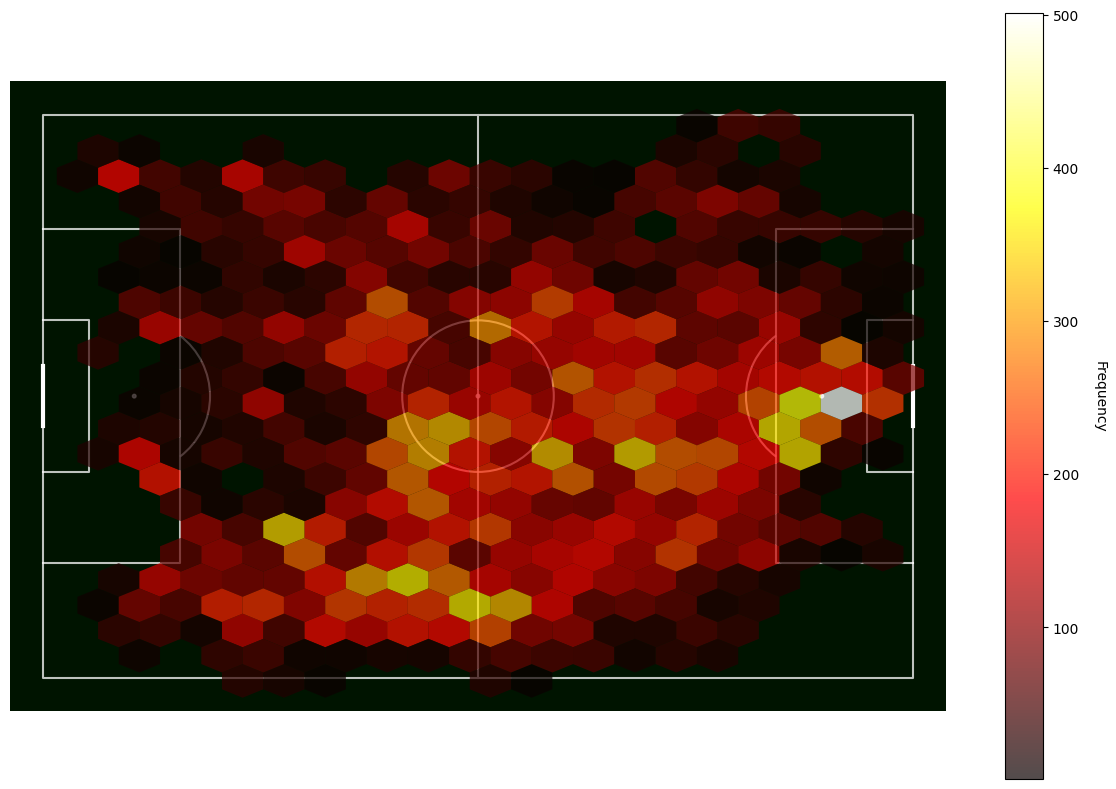

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

import matplotlib.pyplot as plt

# Create pitch
pitch = Pitch(
    pitch_type="skillcorner",
    line_alpha=0.75,
    pitch_length=105,
    pitch_width=68,
    pitch_color="#001400",
    line_color="white",
    linewidth=1.5,
)

# Select a player to visualize
player_id = 23909  # You can change this to any player_id from the tracking data
player_name = processed_players_df[processed_players_df['id'] == player_id]['short_name'].values[0]
player_number = processed_players_df[processed_players_df['id'] == player_id]['number'].values[0]

# Filter tracking data for the selected player
player_tracking = merged_df[
    merged_df['player_id'] == player_id
].copy()

# Adjust coordinates based on direction (similar to what was done in filtered_df)
player_tracking["direction_player"] = np.where(
    player_tracking["period"] == 1,
    player_tracking["direction_player_1st_half"],
    player_tracking["direction_player_2nd_half"],
)
player_tracking["x_adjusted"] = np.where(
    player_tracking["direction_player"] == "right_to_left",
    -player_tracking["x"],
    player_tracking["x"],
)
player_tracking["y_adjusted"] = np.where(
    player_tracking["direction_player"] == "right_to_left",
    -player_tracking["y"],
    player_tracking["y"],
)

# Create figure
fig, ax = pitch.draw(figsize=(12, 8))

# Create heatmap using hexbin
heatmap = ax.hexbin(
    player_tracking['x_adjusted'],
    player_tracking['y_adjusted'],
    gridsize=20,
    cmap='hot',
    alpha=0.7,
    edgecolors='none',
    mincnt=1
)

# Add colorbar
cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label('Frequency', rotation=270, labelpad=20)

# Add title
plt.title(
    f"Heat Map: {player_name} (#{player_number}) - Full Match Movement",
    fontsize=14,
    fontweight='bold',
    color='white'
)

plt.tight_layout()
fig.show()